<a href="https://colab.research.google.com/github/bahmedx/730/blob/main/W5P2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# CELL 1: LIBRARIES AND PROJECT CONFIGURATION
# ============================================================

import pandas as pd
import numpy as np
import requests

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from getpass import getpass
import warnings

warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Analysis period
START_YEAR = 2015
END_YEAR = 2025

# Chronological train/test split
TRAIN_END_YEAR = 2023
TEST_START_YEAR = 2024

# Counterfactual policy scenarios
POLICY_SCENARIOS = {
    "Baseline": 0.00,
    "5% Reduction": 0.05,
    "10% Reduction": 0.10,
    "15% Reduction": 0.15
}

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

print("Project configuration complete.")
print(f"Historical period: {START_YEAR}-{END_YEAR}")
print(f"Training period: {START_YEAR}-{TRAIN_END_YEAR}")
print(f"Testing period: {TEST_START_YEAR}-{END_YEAR}")

Project configuration complete.
Historical period: 2015-2025
Training period: 2015-2023
Testing period: 2024-2025


In [2]:
# ============================================================
# CELL 2: EIA API KEY AND DATA-DOWNLOAD FUNCTION
# ============================================================

EIA_API_KEY = getpass("Enter your EIA API key: ")

if not EIA_API_KEY.strip():
    raise ValueError("A valid EIA API key is required.")


def get_eia_retail_data(api_key, start_year, end_year):
    """
    Download monthly state-level retail electricity data
    from the EIA API using pagination.
    """

    url = "https://api.eia.gov/v2/electricity/retail-sales/data/"

    page_size = 5000
    offset = 0
    all_rows = []

    while True:

        params = [
            ("api_key", api_key),
            ("frequency", "monthly"),
            ("data[0]", "sales"),
            ("data[1]", "revenue"),
            ("data[2]", "price"),
            ("data[3]", "customers"),
            ("start", str(start_year)),
            ("end", str(end_year)),
            ("offset", offset),
            ("length", page_size)
        ]

        response = requests.get(
            url,
            params=params,
            timeout=60
        )

        response.raise_for_status()
        payload = response.json()

        rows = payload.get("response", {}).get("data", [])

        if not rows:
            break

        all_rows.extend(rows)

        print(
            f"Downloaded {len(all_rows):,} records",
            end="\r"
        )

        if len(rows) < page_size:
            break

        offset += page_size

    print(f"\nDownload complete: {len(all_rows):,} records.")

    return pd.DataFrame(all_rows)

Enter your EIA API key: ··········


In [3]:
# ============================================================
# CELL 3: DOWNLOAD HISTORICAL EIA ELECTRICITY DATA
# ============================================================

eia_raw = get_eia_retail_data(
    api_key=EIA_API_KEY,
    start_year=START_YEAR,
    end_year=END_YEAR
)

print("\nRaw dataset shape:")
print(eia_raw.shape)

display(eia_raw.head())

Downloaded 45,012 records
Download complete: 45,012 records.

Raw dataset shape:
(45012, 13)


,period,stateid,stateDescription,sectorid,sectorName,sales,revenue,price,customers,sales-units,revenue-units,price-units,customers-units
0,2025-01,AK,Alaska,ALL,all sectors,566.93865,128.31182,22.63,360406,million kilowatt hours,million dollars,cents per kilowatt-hour,number of customers
1,2025-01,AK,Alaska,COM,commercial,240.06506,52.13928,21.72,58008,million kilowatt hours,million dollars,cents per kilowatt-hour,number of customers
2,2025-01,AK,Alaska,IND,industrial,114.72168,23.69913,20.66,1207,million kilowatt hours,million dollars,cents per kilowatt-hour,number of customers
3,2025-01,AK,Alaska,OTH,other,None,None,None,None,million kilowatt hours,million dollars,cents per kilowatt-hour,number of customers
4,2025-01,AK,Alaska,RES,residential,212.15191,52.47341,24.73,301191,million kilowatt hours,million dollars,cents per kilowatt-hour,number of customers


In [4]:
# ============================================================
# CELL 4: INITIAL DATA INSPECTION
# ============================================================

print("DATASET OVERVIEW")
print("=" * 60)

print(f"Rows: {eia_raw.shape,}")
print(f"Columns: {eia_raw.shape[1]}")

print("\nColumn names:")
print(eia_raw.columns.tolist())

print("\nFirst five observations:")
display(eia_raw.head())

print("\nSector coverage:")
display(
    eia_raw[["sectorid", "sectorName"]]
    .drop_duplicates()
    .sort_values("sectorid")
)

print("\nMissing values:")
missing_raw = pd.DataFrame({
    "Missing": eia_raw.isna().sum(),
    "Percent": (eia_raw.isna().mean() * 100).round(2)
})

display(missing_raw)

DATASET OVERVIEW
Rows: ((45012, 13),)
Columns: 13

Column names:
['period', 'stateid', 'stateDescription', 'sectorid', 'sectorName', 'sales', 'revenue', 'price', 'customers', 'sales-units', 'revenue-units', 'price-units', 'customers-units']

First five observations:


,period,stateid,stateDescription,sectorid,sectorName,sales,revenue,price,customers,sales-units,revenue-units,price-units,customers-units
0,2025-01,AK,Alaska,ALL,all sectors,566.93865,128.31182,22.63,360406,million kilowatt hours,million dollars,cents per kilowatt-hour,number of customers
1,2025-01,AK,Alaska,COM,commercial,240.06506,52.13928,21.72,58008,million kilowatt hours,million dollars,cents per kilowatt-hour,number of customers
2,2025-01,AK,Alaska,IND,industrial,114.72168,23.69913,20.66,1207,million kilowatt hours,million dollars,cents per kilowatt-hour,number of customers
3,2025-01,AK,Alaska,OTH,other,None,None,None,None,million kilowatt hours,million dollars,cents per kilowatt-hour,number of customers
4,2025-01,AK,Alaska,RES,residential,212.15191,52.47341,24.73,301191,million kilowatt hours,million dollars,cents per kilowatt-hour,number of customers



Sector coverage:


,sectorid,sectorName
0,ALL,all sectors
1,COM,commercial
2,IND,industrial
3,OTH,other
4,RES,residential
5,TRA,transportation



Missing values:


,Missing,Percent
period,0,0.00
stateid,0,0.00
stateDescription,0,0.00
sectorid,0,0.00
sectorName,0,0.00
sales,7502,16.67
revenue,7502,16.67
price,7502,16.67
customers,7502,16.67
sales-units,0,0.00


In [5]:
# ============================================================
# CELL 5: CLEAN AND RESHAPE DATA
# ============================================================

df = eia_raw.copy()

# Convert date
df["period"] = pd.to_datetime(
    df["period"],
    errors="coerce"
)

# Convert EIA numerical fields
numeric_cols = ["sales", "revenue", "price", "customers"]

for col in numeric_cols:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

# Standardize text fields
df["sector"] = (
    df["sectorName"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df["state"] = (
    df["stateDescription"]
    .astype(str)
    .str.strip()
)

# Keep residential, commercial, and industrial sectors
keep_sectors = [
    "residential",
    "commercial",
    "industrial"
]

df = df[
    df["sector"].isin(keep_sectors)
].copy()

# Exclude national totals
df = df[
    ~df["state"].isin(
        ["United States", "U.S. Total"]
    )
].copy()

# Create time variables
df["year"] = df["period"].dt.year
df["month"] = df["period"].dt.month

# Reshape to one state-month observation
state_month = df.pivot_table(
    index=["period", "year", "month", "state"],
    columns="sector",
    values=["sales", "price"],
    aggfunc="first"
)

state_month.columns = [
    f"{sector}_{measure}"
    for measure, sector in state_month.columns
]

state_month = (
    state_month
    .reset_index()
    .sort_values(["state", "period"])
    .reset_index(drop=True)
)

print("Clean state-month dataset:")
print(state_month.shape)

display(state_month.head())

Clean state-month dataset:
(7381, 10)


,period,year,month,state,commercial_price,industrial_price,residential_price,commercial_sales,industrial_sales,residential_sales
0,2015-01-01,2015,1,Alabama,10.51,5.53,10.92,1929.03729,2830.20609,3250.39739
1,2015-02-01,2015,2,Alabama,11.02,5.91,11.16,1776.87167,2560.76485,3096.88735
2,2015-03-01,2015,3,Alabama,10.79,5.61,11.70,1772.18420,2757.45787,2480.85645
3,2015-04-01,2015,4,Alabama,10.80,5.69,12.22,1768.82783,2723.13665,1866.59674
4,2015-05-01,2015,5,Alabama,11.00,6.22,12.12,1938.26465,2831.61869,2239.72635


In [6]:
# ============================================================
# CELL 6: MISSING-DATA ANALYSIS AND PREPROCESSING
# ============================================================

required_variables = [
    "residential_price",
    "residential_sales",
    "commercial_sales",
    "industrial_sales"
]

missing_summary = pd.DataFrame({
    "Missing": state_month[required_variables].isna().sum(),
    "Percent": (
        state_month[required_variables]
        .isna()
        .mean()
        .mul(100)
        .round(2)
    )
})

print("Missing-value summary:")
display(missing_summary)

# Remove observations missing variables required for analysis.
# Mean imputation is avoided because it could distort
# state-level electricity demand relationships.

analysis_df = state_month.dropna(
    subset=required_variables
).copy()

# Remove impossible non-positive observations
analysis_df = analysis_df[
    (analysis_df["residential_price"] > 0) &
    (analysis_df["residential_sales"] > 0) &
    (analysis_df["commercial_sales"] > 0) &
    (analysis_df["industrial_sales"] > 0)
].copy()

print(f"Observations retained: {len(analysis_df):,}")
print(f"States/regions: {analysis_df['state'].nunique()}")
print(
    f"Period: {analysis_df['period'].min().date()} "
    f"to {analysis_df['period'].max().date()}"
)

Missing-value summary:


,Missing,Percent
residential_price,0,0.0
residential_sales,0,0.0
commercial_sales,0,0.0
industrial_sales,0,0.0


Observations retained: 7,381
States/regions: 61
Period: 2015-01-01 to 2025-01-01


In [7]:
# ============================================================
# CELL 7: FEATURE ENGINEERING
# ============================================================

analysis_df = (
    analysis_df
    .sort_values(["state", "period"])
    .copy()
)

# Log electricity demand
analysis_df["log_commercial_sales"] = np.log1p(
    analysis_df["commercial_sales"]
)

analysis_df["log_residential_sales"] = np.log1p(
    analysis_df["residential_sales"]
)

analysis_df["log_industrial_sales"] = np.log1p(
    analysis_df["industrial_sales"]
)

# Year-over-year commercial electricity-demand growth
analysis_df["commercial_growth"] = (
    analysis_df
    .groupby("state")["commercial_sales"]
    .pct_change(12)
)

# Lagged residential electricity price
analysis_df["price_lag12"] = (
    analysis_df
    .groupby("state")["residential_price"]
    .shift(12)
)

# Seasonal controls
analysis_df["month_sin"] = np.sin(
    2 * np.pi * analysis_df["month"] / 12
)

analysis_df["month_cos"] = np.cos(
    2 * np.pi * analysis_df["month"] / 12
)

model_variables = [
    "residential_price",
    "log_commercial_sales",
    "log_residential_sales",
    "log_industrial_sales",
    "commercial_growth",
    "price_lag12",
    "month_sin",
    "month_cos"
]

analysis_df = analysis_df.dropna(
    subset=model_variables
).copy()

print(f"Final modeling observations: {len(analysis_df):,}")

display(
    analysis_df[model_variables]
    .describe()
    .T
    .round(3)
)

Final modeling observations: 6,649


,count,mean,std,min,25%,50%,75%,max
residential_price,6649.0,14.947,5.360,7.870,11.580,13.070,16.290,45.590
log_commercial_sales,6649.0,7.518,1.222,4.847,6.586,7.552,8.291,10.459
log_residential_sales,6649.0,7.539,1.281,4.847,6.608,7.636,8.358,10.660
log_industrial_sales,6649.0,7.142,1.378,1.366,6.412,7.232,7.958,10.069
commercial_growth,6649.0,0.009,0.068,-0.272,-0.027,0.005,0.040,0.512
price_lag12,6649.0,14.500,5.010,7.870,11.390,12.780,15.800,45.590
month_sin,6649.0,0.005,0.706,-1.000,-0.500,0.000,0.500,1.000
month_cos,6649.0,0.008,0.709,-1.000,-0.500,0.000,0.866,1.000


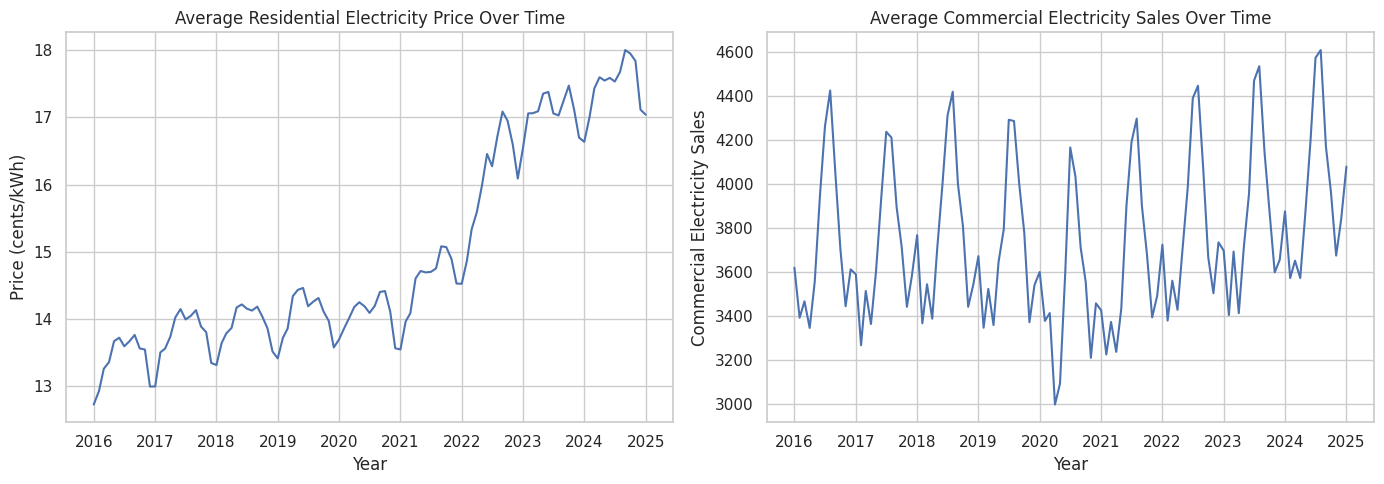

In [8]:
# ============================================================
# CELL 8: EXPLORATORY DATA ANALYSIS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residential electricity price over time
monthly_price = (
    analysis_df
    .groupby("period")["residential_price"]
    .mean()
)

axes[0].plot(
    monthly_price.index,
    monthly_price.values
)

axes[0].set_title(
    "Average Residential Electricity Price Over Time"
)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Price (cents/kWh)")


# Commercial electricity sales over time
monthly_commercial = (
    analysis_df
    .groupby("period")["commercial_sales"]
    .mean()
)

axes[1].plot(
    monthly_commercial.index,
    monthly_commercial.values
)

axes[1].set_title(
    "Average Commercial Electricity Sales Over Time"
)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Commercial Electricity Sales")

plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# CELL 9: TIME-BASED TRAIN/TEST SPLIT
# ============================================================

train_df = analysis_df[
    analysis_df["year"] <= TRAIN_END_YEAR
].copy()

test_df = analysis_df[
    analysis_df["year"] >= TEST_START_YEAR
].copy()

if train_df.empty or test_df.empty:
    raise ValueError(
        "Training or testing dataset is empty. "
        "Check the available years."
    )

print("TRAINING DATA")
print(
    train_df["period"].min().date(),
    "to",
    train_df["period"].max().date()
)
print(f"Observations: {len(train_df):,}")

print("\nTESTING DATA")
print(
    test_df["period"].min().date(),
    "to",
    test_df["period"].max().date()
)
print(f"Observations: {len(test_df):,}")

TRAINING DATA
2016-01-01 to 2023-12-01
Observations: 5,856

TESTING DATA
2024-01-01 to 2025-01-01
Observations: 793


In [10]:
# ============================================================
# CELL 10: NORMALIZE MODEL PREDICTORS
# ============================================================

continuous_features = [
    "log_commercial_sales",
    "log_residential_sales",
    "log_industrial_sales",
    "commercial_growth",
    "price_lag12"
]

scaler = StandardScaler()

train_scaled = train_df.copy()
test_scaled = test_df.copy()

# Fit scaler only on training observations
train_scaled[continuous_features] = (
    scaler.fit_transform(
        train_df[continuous_features]
    )
)

# Apply same transformation to test observations
test_scaled[continuous_features] = (
    scaler.transform(
        test_df[continuous_features]
    )
)

print("Predictors normalized successfully.")

print("\nStandardized training means:")
display(
    train_scaled[
        continuous_features
    ].mean().round(3).to_frame("Mean")
)

Predictors normalized successfully.

Standardized training means:


,Mean
log_commercial_sales,-0.0
log_residential_sales,0.0
log_industrial_sales,0.0
commercial_growth,-0.0
price_lag12,-0.0


In [13]:
# ============================================================
# CELL 11: MODEL IMPLEMENTATION
# ============================================================

# Panel-style regression model
# C(state) controls for persistent differences across states.
# Month sine/cosine terms control for seasonality.
#
# C(year) is intentionally NOT included because the model is
# trained on earlier years and tested on future years.
# Including year as a categorical fixed effect would prevent
# prediction for years not observed during training.

formula = """
residential_price
~ log_commercial_sales
+ log_residential_sales
+ log_industrial_sales
+ commercial_growth
+ price_lag12
+ month_sin
+ month_cos
+ C(state)
"""

price_model = smf.ols(
    formula=formula,
    data=train_scaled
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": train_scaled["state"]
    }
)

print("Model fitted successfully.")
print(f"Training observations: {int(price_model.nobs):,}")
print(f"Adjusted R²: {price_model.rsquared_adj:.3f}")

Model fitted successfully.
Training observations: 5,856
Adjusted R²: 0.945


MODEL PERFORMANCE
Training R²: 0.945
Testing R²:  0.936
Testing MAE: 0.957 cents/kWh
Testing RMSE: 1.654 cents/kWh


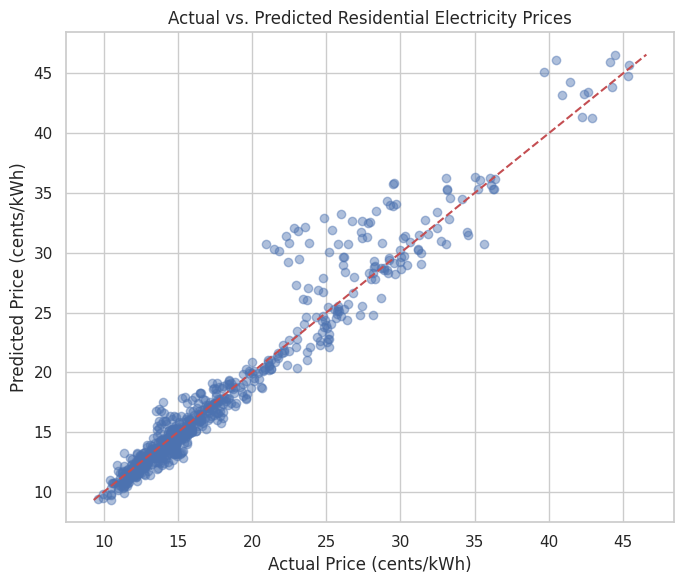

In [14]:
# ============================================================
# CELL 12: MODEL EVALUATION
# ============================================================

train_predictions = price_model.predict(
    train_scaled
)

test_predictions = price_model.predict(
    test_scaled
)

train_r2 = r2_score(
    train_scaled["residential_price"],
    train_predictions
)

test_r2 = r2_score(
    test_scaled["residential_price"],
    test_predictions
)

test_mae = mean_absolute_error(
    test_scaled["residential_price"],
    test_predictions
)

test_rmse = np.sqrt(
    mean_squared_error(
        test_scaled["residential_price"],
        test_predictions
    )
)

print("MODEL PERFORMANCE")
print("=" * 45)
print(f"Training R²: {train_r2:.3f}")
print(f"Testing R²:  {test_r2:.3f}")
print(f"Testing MAE: {test_mae:.3f} cents/kWh")
print(f"Testing RMSE: {test_rmse:.3f} cents/kWh")


# Actual vs. predicted plot
plt.figure(figsize=(7, 6))

plt.scatter(
    test_scaled["residential_price"],
    test_predictions,
    alpha=0.45
)

low = min(
    test_scaled["residential_price"].min(),
    test_predictions.min()
)

high = max(
    test_scaled["residential_price"].max(),
    test_predictions.max()
)

plt.plot(
    [low, high],
    [low, high],
    "r--"
)

plt.title(
    "Actual vs. Predicted Residential Electricity Prices"
)
plt.xlabel("Actual Price (cents/kWh)")
plt.ylabel("Predicted Price (cents/kWh)")

plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# CELL 13: MAIN MODEL COEFFICIENTS
# ============================================================

main_variables = [
    "log_commercial_sales",
    "log_residential_sales",
    "log_industrial_sales",
    "commercial_growth",
    "price_lag12",
    "month_sin",
    "month_cos"
]

coef_table = pd.DataFrame({
    "Coefficient": price_model.params[main_variables],
    "Std. Error": price_model.bse[main_variables],
    "P-value": price_model.pvalues[main_variables]
})

coef_table["Significant at 5%"] = (
    coef_table["P-value"] < 0.05
)

display(
    coef_table.round(4)
)

,Coefficient,Std. Error,P-value,Significant at 5%
log_commercial_sales,-0.4511,0.9772,0.6444,False
log_residential_sales,-0.0013,0.2608,0.9960,False
log_industrial_sales,-1.1785,0.5945,0.0475,True
commercial_growth,0.1050,0.0567,0.0638,False
price_lag12,4.6223,0.2791,0.0000,True
month_sin,-0.0504,0.0555,0.3638,False
month_cos,-0.0221,0.0401,0.5816,False


In [23]:
# ============================================================
# CELL 14: COUNTERFACTUAL POLICY SIMULATION
# ============================================================

def prepare_for_prediction(data):
    """
    Apply the scaler fitted on the training data
    to continuous predictors before prediction.
    """
    data_scaled = data.copy()

    data_scaled[continuous_features] = scaler.transform(
        data_scaled[continuous_features]
    )

    return data_scaled


# ------------------------------------------------------------
# Baseline predictions using observed test-period conditions
# ------------------------------------------------------------

baseline_data = prepare_for_prediction(test_df)

baseline_predictions = price_model.predict(
    baseline_data
)


# ------------------------------------------------------------
# Generate counterfactual policy scenarios
# ------------------------------------------------------------

results = []

for scenario, reduction in POLICY_SCENARIOS.items():

    # Start with the original, unscaled test observations
    cf = test_df.copy()

    # Apply hypothetical reduction in commercial electricity demand
    cf["commercial_sales"] = (
        cf["commercial_sales"] * (1 - reduction)
    )

    # Recalculate the transformed commercial-demand feature
    cf["log_commercial_sales"] = np.log1p(
        cf["commercial_sales"]
    )

    # Apply the scaler fitted on the training data
    cf_scaled = prepare_for_prediction(cf)

    # Generate counterfactual residential-price predictions
    cf_predictions = price_model.predict(cf_scaled)

    # Store scenario-level results
    results.append({
        "Scenario": scenario,
        "Demand Reduction (%)": reduction * 100,
        "Predicted Price (cents/kWh)": cf_predictions.mean(),
        "Price Change (cents/kWh)": (
            cf_predictions - baseline_predictions
        ).mean()
    })


# ------------------------------------------------------------
# Create final scenario-results dataset
# ------------------------------------------------------------

scenario_results = pd.DataFrame(results)

baseline_mean = baseline_predictions.mean()

scenario_results["Price Change (%)"] = (
    scenario_results["Price Change (cents/kWh)"]
    / baseline_mean
    * 100
)

print(
    f"Counterfactual simulation completed for "
    f"{len(scenario_results)} scenarios."
)

Counterfactual simulation completed for 4 scenarios.


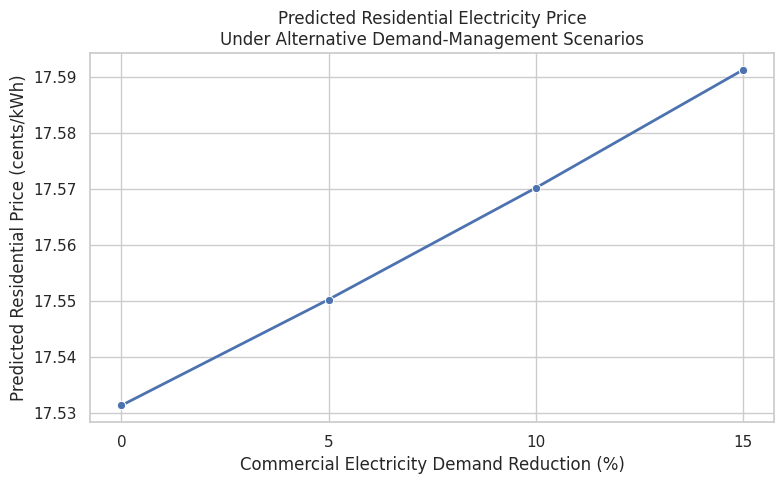

In [17]:
# ============================================================
# CELL 15: COUNTERFACTUAL RESULTS VISUALIZATION
# ============================================================

plt.figure(figsize=(8, 5))

sns.lineplot(
    data=scenario_results,
    x="Demand Reduction (%)",
    y="Predicted Price (cents/kWh)",
    marker="o",
    linewidth=2
)

plt.title(
    "Predicted Residential Electricity Price\n"
    "Under Alternative Demand-Management Scenarios"
)

plt.xlabel(
    "Commercial Electricity Demand Reduction (%)"
)

plt.ylabel(
    "Predicted Residential Price (cents/kWh)"
)

plt.xticks(
    scenario_results["Demand Reduction (%)"]
)

plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# CELL 16: FINAL RESULTS SUMMARY
# ============================================================

# Extract baseline and primary 10% policy scenario
baseline = scenario_results.loc[
    scenario_results["Scenario"] == "Baseline"
].iloc[0]

policy_10 = scenario_results.loc[
    scenario_results["Scenario"] == "10% Reduction"
].iloc[0]


# ------------------------------------------------------------
# Model performance
# ------------------------------------------------------------

print("COUNTERFACTUAL ANALYSIS RESULTS")
print("=" * 60)

print("\nMODEL PERFORMANCE")
print("-" * 30)

print(f"Test R²:   {test_r2:.3f}")
print(f"Test MAE:  {test_mae:.3f} cents/kWh")
print(f"Test RMSE: {test_rmse:.3f} cents/kWh")


# ------------------------------------------------------------
# Baseline and primary policy scenario
# ------------------------------------------------------------

print("\nBASELINE")
print("-" * 30)

print(
    f"Predicted residential electricity price: "
    f"{baseline['Predicted Price (cents/kWh)']:.3f} cents/kWh"
)


print("\n10% DEMAND-REDUCTION SCENARIO")
print("-" * 30)

print(
    f"Predicted residential electricity price: "
    f"{policy_10['Predicted Price (cents/kWh)']:.3f} cents/kWh"
)

print(
    f"Price change: "
    f"{policy_10['Price Change (cents/kWh)']:.3f} cents/kWh"
)

print(
    f"Percentage change: "
    f"{policy_10['Price Change (%)']:.2f}%"
)


# ------------------------------------------------------------
# Complete counterfactual results
# ------------------------------------------------------------

print("\nALL COUNTERFACTUAL SCENARIOS")
print("-" * 30)

final_results = scenario_results.copy()

display(
    final_results.round({
        "Demand Reduction (%)": 1,
        "Predicted Price (cents/kWh)": 3,
        "Price Change (cents/kWh)": 3,
        "Price Change (%)": 2
    })
)

COUNTERFACTUAL ANALYSIS RESULTS

MODEL PERFORMANCE
------------------------------
Test R²:   0.936
Test MAE:  0.957 cents/kWh
Test RMSE: 1.654 cents/kWh

BASELINE
------------------------------
Predicted residential electricity price: 17.531 cents/kWh

10% DEMAND-REDUCTION SCENARIO
------------------------------
Predicted residential electricity price: 17.570 cents/kWh
Price change: 0.039 cents/kWh
Percentage change: 0.22%

ALL COUNTERFACTUAL SCENARIOS
------------------------------


,Scenario,Demand Reduction (%),Predicted Price (cents/kWh),Price Change (cents/kWh),Price Change (%)
0,Baseline,0.0,17.531,0.000,0.00
1,5% Reduction,5.0,17.550,0.019,0.11
2,10% Reduction,10.0,17.570,0.039,0.22
3,15% Reduction,15.0,17.591,0.060,0.34
